In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import aymansigmri as asm

In [2]:
def generate_zte_data_trial(ksp, coord,n_missing,undersampling_factor=1):

    n_spokes, n_points, n_dims = coord.shape
    n_coils = ksp.shape[0]
    half = n_points // 2

    ksp_new = np.zeros((n_coils,n_spokes * 2, half), dtype=ksp.dtype)
    coord_new = np.zeros((n_spokes * 2, half, n_dims), dtype=coord.dtype)
    
    for coil_index in range(n_coils):
        for spoke_index in range(n_spokes):
            spoke_a, spoke_b, coords_a, coords_b = asm.spoke_split(ksp[coil_index,spoke_index], coord[spoke_index])
            
            b_index = asm.get_spoke_b_index(spoke_index, n_spokes)

            ksp_new[coil_index, spoke_index] = spoke_a
            ksp_new[coil_index,b_index] = spoke_b

            coord_new[spoke_index] = coords_a
            coord_new[b_index] = coords_b
    
    coord_full = coord_new.copy()
    ksp_full = ksp_new.copy()
    ksp_groundtruth = ksp_new.copy()
    ksp_full[:, :, :n_missing] = 0


    ksp_new, coord_new = asm.point_remove(kspacedata=ksp_new, coord_data=coord_new, n=n_missing)
    ksp_new, coord_new = asm.spoke_remove(kspacedata=ksp_new, coord_data=coord_new, unsampling=undersampling_factor)

    coord_full = coord_full[::undersampling_factor]
    ksp_full = ksp_full[:, ::undersampling_factor, :]

    n_spokes_full = coord_full.shape[0]
    n_points_full = coord_full.shape[1]
    acquired_mask = np.ones((n_spokes_full, n_points_full), dtype=bool)
    acquired_mask[:, :n_missing] = False

    return ksp_new, coord_new, ksp_full, coord_full, acquired_mask, ksp_groundtruth, n_points_full


In [3]:
zte_radial_kspace, zte_radial_coords, full_zte_radial_kspace, full_zte_radial_coords, zte_mask, groundtruth_radial, n_points_full = generate_zte_data_trial(ksp=ksp, coord=coord, n_missing=1, undersampling_factor=1)

In [4]:
dcf = (full_zte_radial_coords[...,0]**2 + full_zte_radial_coords[...,1]**2)**0.5
'''zte_missing_im_grid = sp.nufft_adjoint(full_zte_radial_kspace* dcf, full_zte_radial_coords)

img_rss = np.sum(np.abs(zte_missing_im_grid)**2, axis=0)**0.5
pl.ImagePlot(img_rss, title='test')'''

"zte_missing_im_grid = sp.nufft_adjoint(full_zte_radial_kspace* dcf, full_zte_radial_coords)\n\nimg_rss = np.sum(np.abs(zte_missing_im_grid)**2, axis=0)**0.5\npl.ImagePlot(img_rss, title='test')"

### Trial - One Iter

In [5]:
win = 8

kspace_cart_coils = asm.nufft_gridding(kspace=full_zte_radial_kspace, coords=full_zte_radial_coords)

hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=kspace_cart_coils, w=win)

U, S_reduced, Vh = asm.sig_val_thresholding(data=hankel_matrix, zero_thresh=0.5)
data_recon = (U * S_reduced) @ Vh

kspace_cart_coils_recon = asm.hankel_H(data_recon, n_coils=kspace_cart_coils.shape[0], Nx=kspace_cart_coils.shape[1], Ny=kspace_cart_coils.shape[2], w=win)

post_operations_radial_ksp = asm.nufft_degridding(cartesian_kspace=kspace_cart_coils_recon, coords=full_zte_radial_coords)

concistent_kspace = asm.data_consistency(kspace_radial=post_operations_radial_ksp, kspace_radial_acquired=full_zte_radial_kspace, mask=zte_mask)

In [6]:
print("First 5 points (zte):")
print(zte_radial_kspace[0, 0, :2])

print("First 5 points (original):")
print(full_zte_radial_kspace[0, 0, :2])

print("First 5 points (post corr):")
print(concistent_kspace[0, 0, :2])


print("Last 5 points (original):")
print(full_zte_radial_kspace[0, 0, -2:])

print("Last 5 points (post op):")
print(post_operations_radial_ksp[0, 0, -2:])

print("Last 5 points (post corr):")
print(concistent_kspace[0, 0, -2:])

First 5 points (zte):
[0.00044332-0.00330292j 0.00085428-0.00126654j]
First 5 points (original):
[0.        +0.j         0.00044332-0.00330292j]
First 5 points (post corr):
[-0.04674105-0.0766959j   0.00044332-0.00330292j]
Last 5 points (original):
[-2.14725428e-06+5.96852547e-06j  2.50665471e-06+4.28687781e-06j]
Last 5 points (post op):
[2.5629194e-04+0.00013333j 4.5070028e-05+0.0004801j ]
Last 5 points (post corr):
[-2.1472542e-06+5.9685253e-06j  2.5066547e-06+4.2868778e-06j]


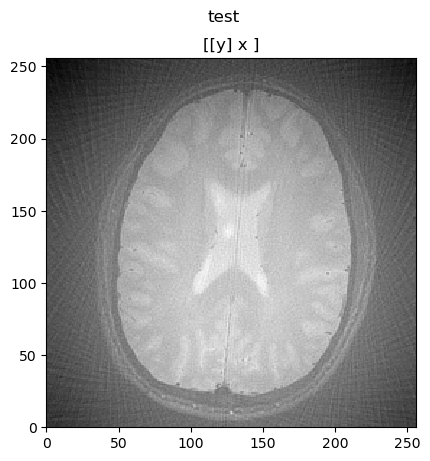

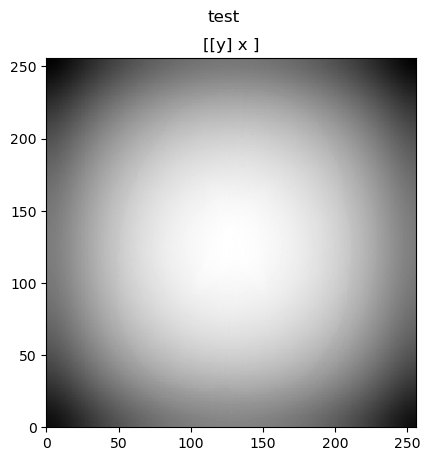

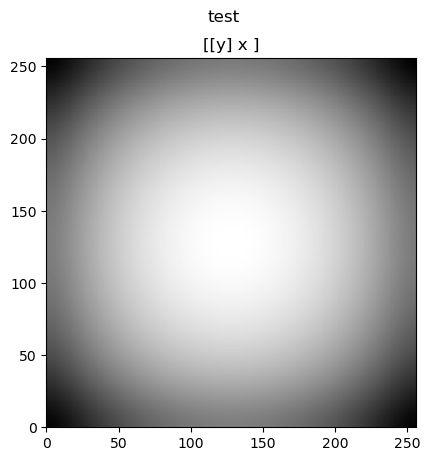

In [ ]:
n_iters = 3
kspace_radial = full_zte_radial_kspace.copy()
iter_count = 0

corrected_vals = []

while iter_count < n_iters:
    kspace_cart_coils = asm.nufft_gridding(kspace=kspace_radial, coords=full_zte_radial_coords)
    hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=kspace_cart_coils, w=5)

    U, S_reduced, Vh = asm.sig_val_thresholding(data=hankel_matrix, zero_thresh=0.15)
    data_recon = (U * S_reduced) @ Vh

    kspace_cart_coils_recon = asm.hankel_H(data_recon, n_coils=kspace_cart_coils.shape[0], Nx=kspace_cart_coils.shape[1], Ny=kspace_cart_coils.shape[2], w=5)

    post_operations_radial_ksp = asm.nufft_degridding(cartesian_kspace=kspace_cart_coils_recon, coords=full_zte_radial_coords)

    kspace_radial = asm.data_consistency(kspace_radial=post_operations_radial_ksp, kspace_radial_acquired=full_zte_radial_kspace, mask=zte_mask)

    iter_count += 1

    grid_recon = sp.nufft_adjoint(kspace_radial * dcf, full_zte_radial_coords)
    img_rss_recon = np.sum(np.abs(grid_recon)**2, axis=0)**0.5
    pl.ImagePlot(img_rss_recon, title='test')
    corrected_vals.append(kspace_radial[0,0,:1])

In [7]:
corrected_vals

NameError: name 'corrected_vals' is not defined

In [ ]:
kspace_radial[0,0,:1]
zte_radial_kspace[0,0,:1]
full_zte_radial_kspace[0,0,:10]
groundtruth_radial[0,0,:10]

array([-8.69957625e-04-3.95396934e-03j,  4.43324768e-04-3.30291778e-03j,
        8.54281952e-04-1.26653845e-03j,  3.47764993e-04+3.43731474e-04j,
       -2.34338492e-04+5.87723864e-04j, -2.91244018e-04+3.87074442e-05j,
       -3.63054816e-05-3.11490153e-04j,  9.00072117e-05-1.86680729e-04j,
        4.81151921e-05+4.38657785e-05j,  7.14646288e-06+1.21855936e-04j])

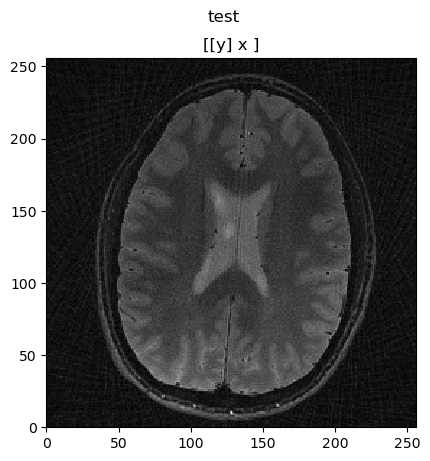

In [ ]:
debug_kspace = kspace_radial.copy()

debug_kspace[:,:,:1] = 0

grid_recon = sp.nufft_adjoint(debug_kspace* dcf, full_zte_radial_coords)
img_rss_recon = np.sum(np.abs(grid_recon)**2, axis=0)**0.5
pl.ImagePlot(img_rss_recon, title='test')

In [ ]:
print("First 5 points (real):")
print(zte_radial_kspace[0, 0, :5])

print("First 5 points (original):")
print(full_zte_radial_kspace[0, 0, :5])

print("First 5 points (post corr):")
print(concistent_kspace[0, 0, :5])


print("Last 5 points (original):")
print(full_zte_radial_kspace[0, 0, -5:])

print("Last 5 points (post op):")
print(post_operations_radial_ksp[0, 0, -5:])

print("Last 5 points (post corr):")
print(concistent_kspace[0, 0, -5:])

First 5 points (real):
[ 0.00044332-3.30291778e-03j  0.00085428-1.26653845e-03j
  0.00034776+3.43731474e-04j -0.00023434+5.87723864e-04j
 -0.00029124+3.87074442e-05j]
First 5 points (original):
[ 0.        +0.j          0.00044332-0.00330292j  0.00085428-0.00126654j
  0.00034776+0.00034373j -0.00023434+0.00058772j]
First 5 points (post corr):
[-0.02813297-0.14507411j  0.00044332-0.00330292j  0.00085428-0.00126654j
  0.00034776+0.00034373j -0.00023434+0.00058772j]
Last 5 points (original):
[-1.30791374e-06-3.16910891e-06j -1.30838844e-06-6.96438409e-07j
  5.75041208e-07-2.48168695e-06j -2.14725428e-06+5.96852547e-06j
  2.50665471e-06+4.28687781e-06j]
Last 5 points (post op):
[-9.0506002e-03-0.00168632j  5.5668801e-01-0.24774717j
  2.0093910e-04+0.00652895j -5.5398744e-01+0.23868747j
 -2.0328448e-03-0.00598779j]
Last 5 points (post corr):
[-1.3079137e-06-3.1691088e-06j -1.3083884e-06-6.9643841e-07j
  5.7504121e-07-2.4816870e-06j -2.1472542e-06+5.9685253e-06j
  2.5066547e-06+4.2868778e-06

### Use only first 20%

In [ ]:
def data_consistency_trial(kspace_radial, kspace_radial_acquired, mask):
    kspace_consistent = kspace_radial.copy()
    kspace_consistent[:, mask] = kspace_radial_acquired[:, mask]
    return kspace_consistent

In [8]:
def sig_val_thresholding_full(data, zero_thresh):
    U, Sigma, Vh = np.linalg.svd(data, full_matrices=True)
    max_val = np.max(Sigma)
    thresh = max_val*zero_thresh
    arr = []
    for i in range(len(Sigma)):
        if Sigma[i] > thresh:
            arr.append(Sigma[i])
        else: arr.append(0)
    S_reduced = np.array(arr)
    return(U, S_reduced, Vh)

In [12]:
n_points_use = int(n_points_full * 0.2)
zte_radial_kspace_partial = zte_radial_kspace[:, :, :n_points_use]
zte_radial_coords_partial = zte_radial_coords[:, :n_points_use, :]
zte_mask_partial = zte_mask[:, :n_points_use]


n_iters = 5
kspace_radial = zte_radial_kspace_partial.copy()
iter_count = 0
win=10


corrected_vals = []
dcf_partial = (zte_radial_coords_partial[...,0]**2 + zte_radial_coords_partial[...,1]**2)**0.5
while iter_count < n_iters:
    kspace_cart_coils = asm.nufft_gridding(kspace=kspace_radial, coords=zte_radial_coords_partial)
    hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=kspace_cart_coils, w=win)

    U, S_reduced, Vh = asm.sig_val_thresholding(data=hankel_matrix, zero_thresh=0.15)
    data_recon = (U * S_reduced) @ Vh

    kspace_cart_coils_recon = asm.hankel_H_averaged(data_recon, n_coils=kspace_cart_coils.shape[0], Nx=kspace_cart_coils.shape[1], Ny=kspace_cart_coils.shape[2], w=win)

    post_operations_radial_ksp = asm.nufft_degridding(cartesian_kspace=kspace_cart_coils_recon, coords=zte_radial_coords_partial)

    kspace_radial = asm.data_consistency(kspace_radial=post_operations_radial_ksp, kspace_radial_acquired=zte_radial_kspace_partial, mask=zte_mask_partial)

    iter_count += 1

    #grid_recon = sp.nufft_adjoint(zte_radial_kspace_partial * dcf_partial, zte_radial_coords_partial)
    #img_rss_recon = np.sum(np.abs(grid_recon)**2, axis=0)**0.5
    #pl.ImagePlot(img_rss_recon, title='test')
    corrected_vals.append(kspace_radial[0,0,:1])

In [34]:
corrected_vals

[array([0.0398051-0.11214005j], dtype=complex64),
 array([1.3210977-4.6323857j], dtype=complex64),
 array([51.103443-166.33667j], dtype=complex64),
 array([2073.3457-5807.296j], dtype=complex64),
 array([83713.89-202015.02j], dtype=complex64)]